<img src="https://devra.ai/analyst/notebook/1792/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;"><div style="font-size:150%; color:#FEE100"><b>Satellite Telemetry Data Anomaly Analysis and Prediction Notebook</b></div><div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

I have always found it fascinating how raw telemetry data can hide subtle signals of anomalies. In this notebook, we explore a satellite telemetry dataset, perform extensive exploratory data analysis, and build a predictor to detect anomalies in the data. If you find this analysis useful, please consider upvoting it.

# Table of Contents

- [Data Overview](#Data-Overview)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Prediction Model](#Prediction-Model)
- [Conclusion](#Conclusion)

In [1]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # Using Agg backend for matplotlib if necessary
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switch backend if only plt is imported

import seaborn as sns

# For machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# Ensure inline plotting on Kaggle
%matplotlib inline

# Set plot style
sns.set(style='whitegrid')

## Data Overview

In [2]:
# Load segments.csv
# This file contains individual telemetry segments along with timestamps.
segments_path = '/kaggle/input/satellite-telemetry-data-anomaly-prediction/segments.csv'
segments_df = pd.read_csv(segments_path)

# Display the first few rows to understand the structure
print('Segments DataFrame Shape:', segments_df.shape)
print(segments_df.head())

# Convert the timestamp column to datetime if it is not already converted
# This is a common error point if the timestamp is not in a standard format
try:
    segments_df['timestamp'] = pd.to_datetime(segments_df['timestamp'])
except Exception as e:
    print('Error converting timestamp to datetime:', e)
    # Note: Using pd.to_datetime with errors='coerce' might be an alternative method to avoid conversion errors.

# Check the data types after conversion
print(segments_df.dtypes)

Segments DataFrame Shape: (303493, 8)
    channel                 timestamp     value    label  sampling  anomaly  \
0  CADC0872  2022-06-01T23:42:54.000Z -0.000021  anomaly         1        1   
1  CADC0872  2022-06-01T23:42:55.000Z -0.000021  anomaly         1        1   
2  CADC0872  2022-06-01T23:42:56.000Z -0.000021  anomaly         1        1   
3  CADC0872  2022-06-01T23:42:57.000Z -0.000021  anomaly         1        1   
4  CADC0872  2022-06-01T23:42:58.000Z -0.000021  anomaly         1        1   

   segment  train  
0        1      1  
1        1      1  
2        1      1  
3        1      1  
4        1      1  
channel                   object
timestamp    datetime64[ns, UTC]
value                    float64
label                     object
sampling                   int64
anomaly                    int64
segment                    int64
train                      int64
dtype: object


## Data Cleaning and Preprocessing

In [3]:
# Load dataset.csv
# This file provides aggregated features for each segment including statistical summaries
dataset_path = '/kaggle/input/satellite-telemetry-data-anomaly-prediction/dataset.csv'
df = pd.read_csv(dataset_path)

# Inspect the first few rows and summary information
print('Dataset Shape:', df.shape)
print(df.head())

# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# No explicit cleaning needed if there are no missing values. If there are, methods such as imputation could be applied.

Dataset Shape: (2123, 23)
   segment  anomaly  train   channel  sampling  duration  len          mean  \
0        1        1      1  CADC0872         1       279  280  8.533143e-07   
1        2        1      1  CADC0872         1       476  477 -3.639396e-06   
2        3        1      1  CADC0872         1       594  595  1.170788e-05   
3        4        1      1  CADC0872         1       271  272  8.486808e-07   
4        5        0      0  CADC0872         1       256  257  1.058485e-05   

            var       std  ...  smooth10_n_peaks  smooth20_n_peaks  \
0  3.494283e-10  0.000019  ...                 3                 2   
1  6.476485e-10  0.000025  ...                 1                 1   
2  5.592877e-10  0.000024  ...                 2                 2   
3  5.466024e-10  0.000023  ...                 2                 2   
4  5.279023e-10  0.000023  ...                 1                 1   

   diff_peaks  diff2_peaks      diff_var     diff2_var  gaps_squared  \
0     

## Exploratory Data Analysis

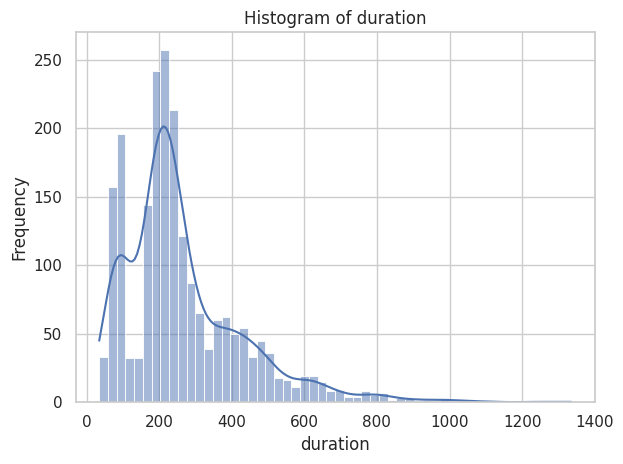

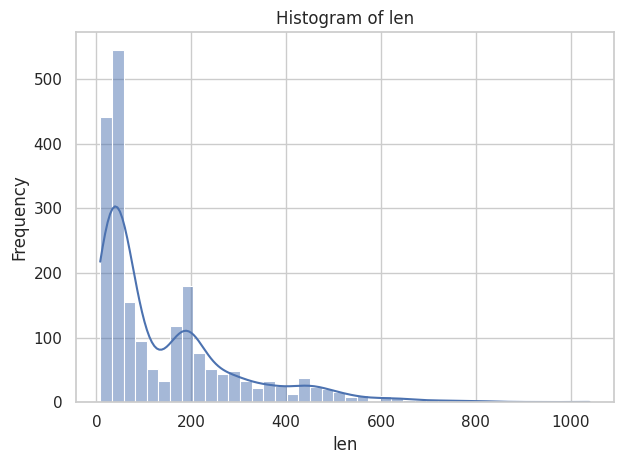

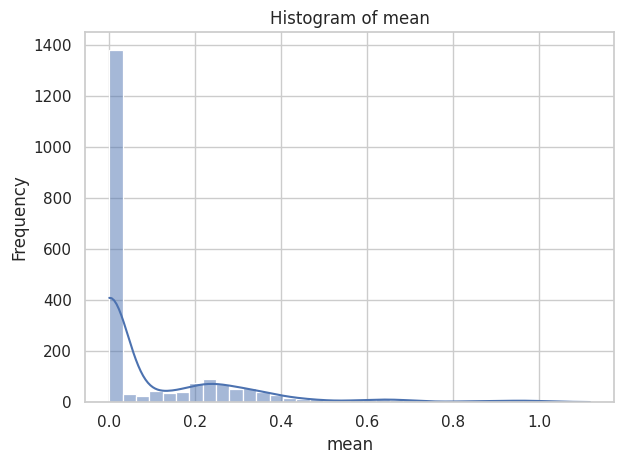

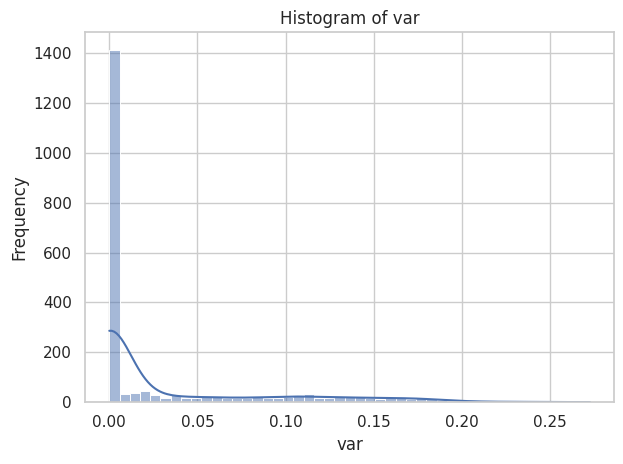

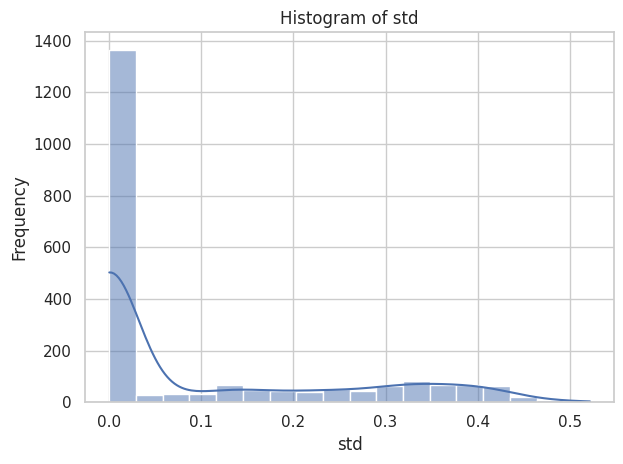

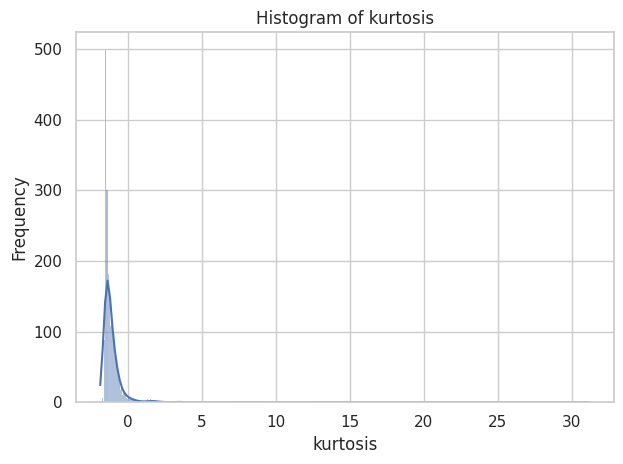

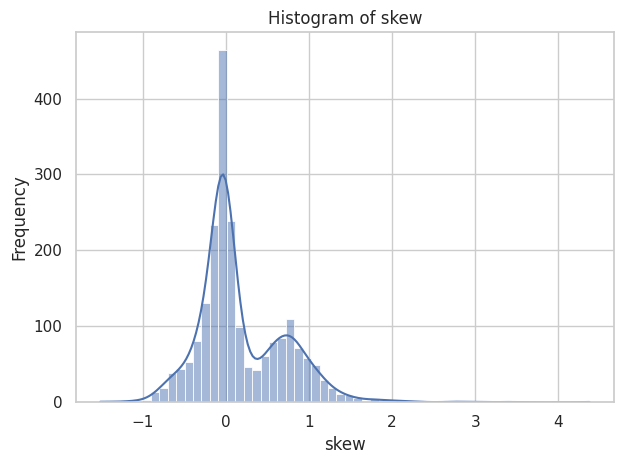

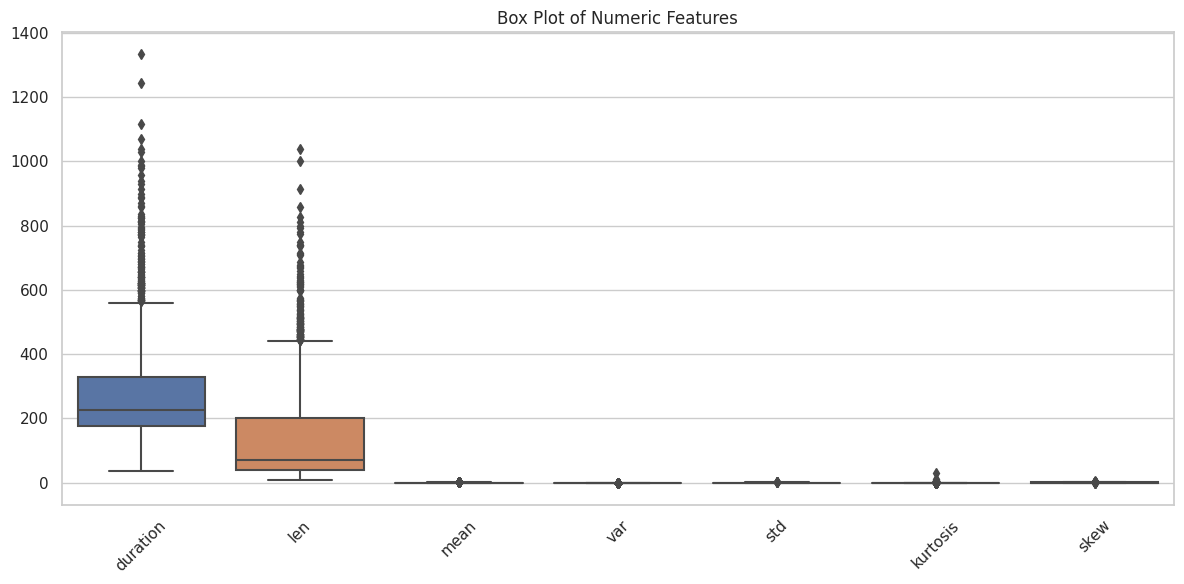

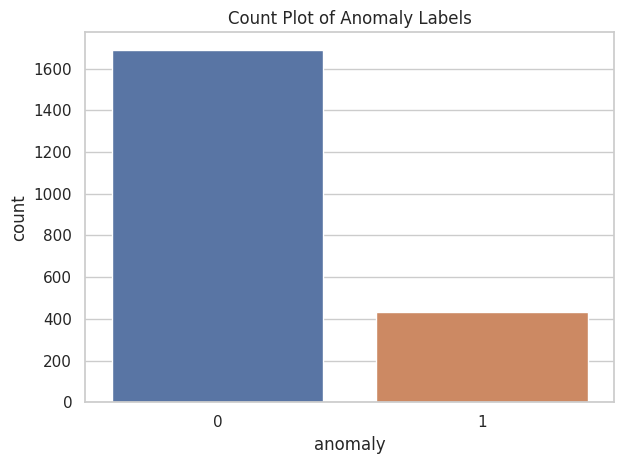

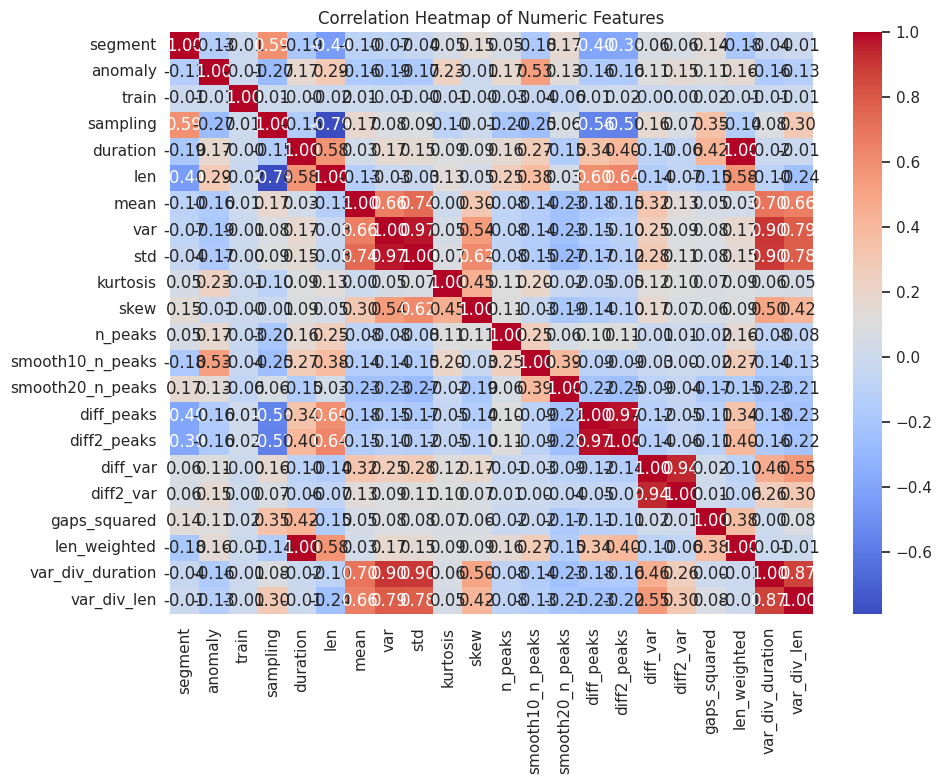

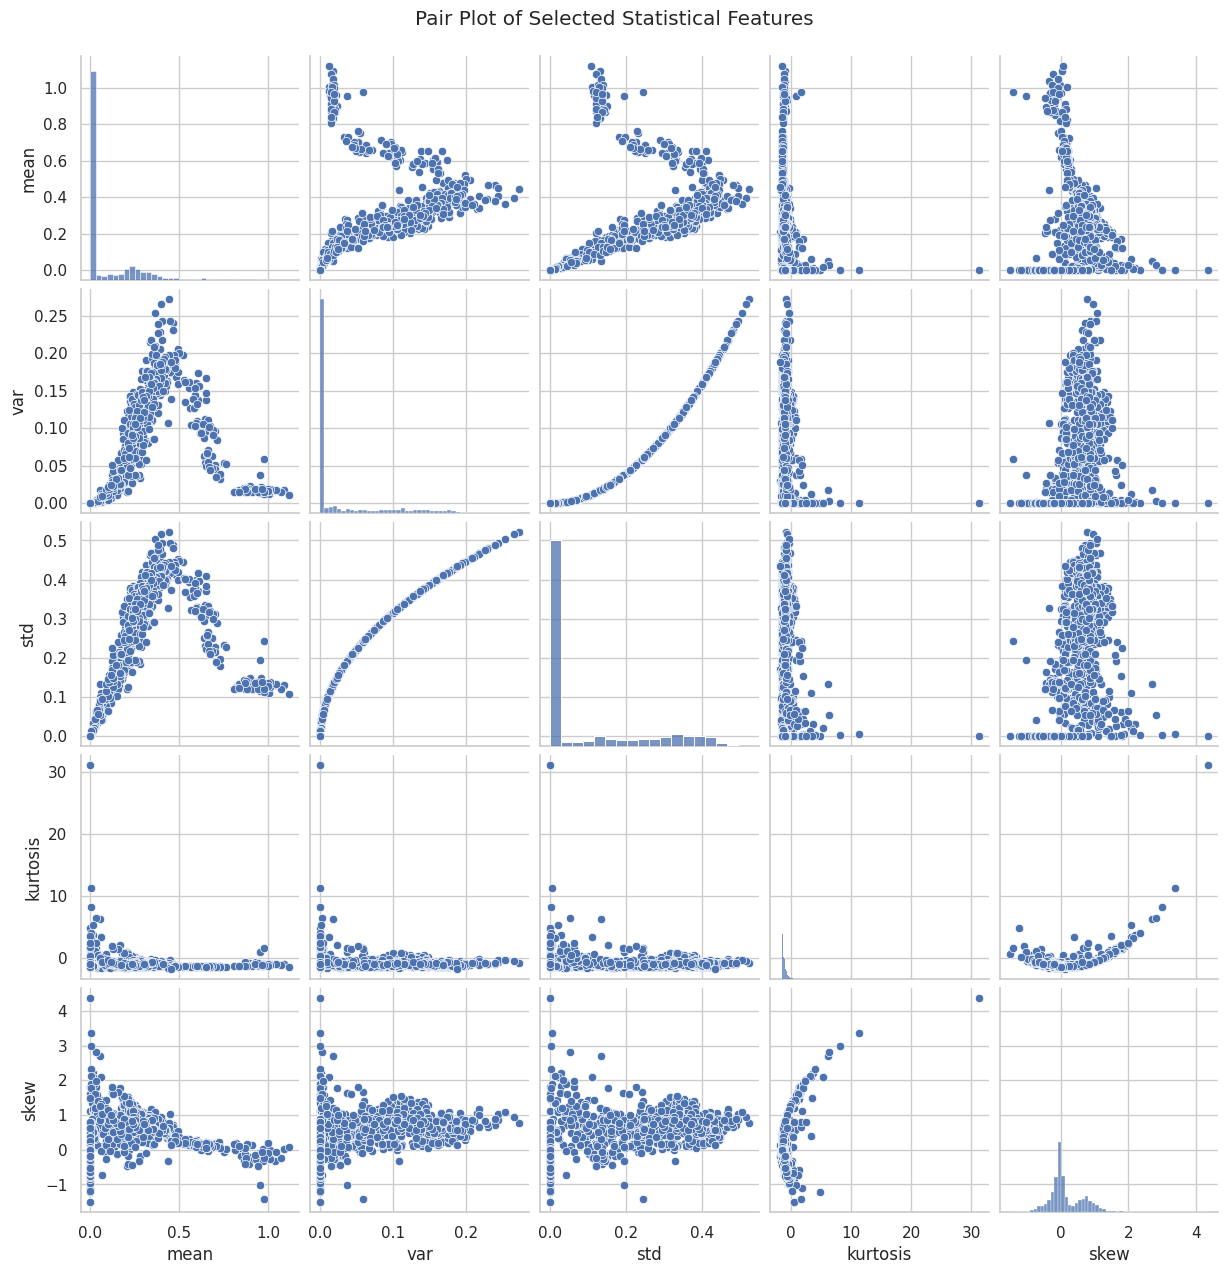

In [4]:
# Let's perform a variety of visualizations on the dataset

## Histogram of select numeric features
numeric_features = ['duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew']
for feature in numeric_features:
    plt.figure()
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## Box Plot for numeric features to view outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_features])
plt.title('Box Plot of Numeric Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Count Plot for anomaly labels
plt.figure()
sns.countplot(x='anomaly', data=df)
plt.title('Count Plot of Anomaly Labels')
plt.tight_layout()
plt.show()

## Correlation Heatmap (only if 4 or more numeric columns are present)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

## Pair Plot for visualizing relationships between select features
sample_features = ['mean', 'var', 'std', 'kurtosis', 'skew']
sns.pairplot(df[sample_features].dropna())
plt.suptitle('Pair Plot of Selected Statistical Features', y=1.02)
plt.show()

# Note: In some cases, if there are too many features, pair plots may become cluttered. Use with a small subset.

## Prediction Model

Validation Accuracy: 0.9467


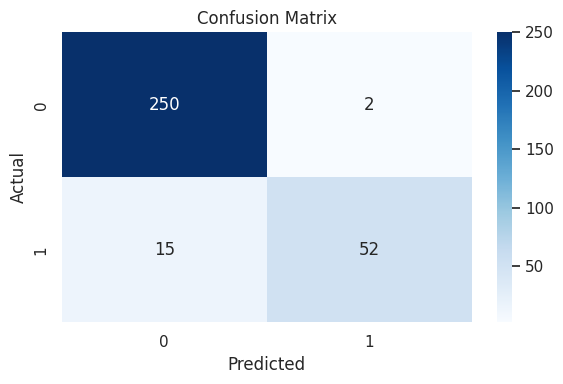

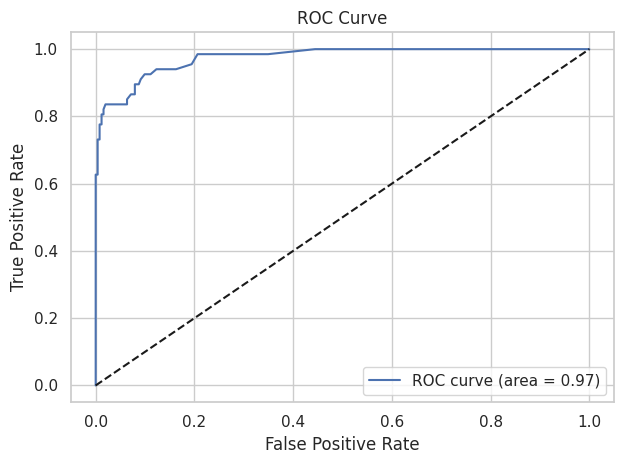

In [5]:
# Building a prediction model to detect anomalies
# We will use the aggregated features in df to predict the 'anomaly' column.
# Here, we assume that segments with train == 1 are used for training and train == 0 for testing.

# Separate the data into training and testing sets based on the 'train' column
train_df = df[df['train'] == 1].copy()
test_df = df[df['train'] == 0].copy()

# Specify features to use in the prediction. We exclude columns that are identifiers or target variables
features = [col for col in df.columns if col not in ['segment', 'anomaly', 'train', 'channel']]

# Further restrict to numeric columns to avoid complications with unencoded categorical data
train_X = train_df[features].select_dtypes(include=[np.number])
train_y = train_df['anomaly']

test_X = test_df[features].select_dtypes(include=[np.number])
test_y = test_df['anomaly']

# Split train data further into training and validation sets to evaluate performance
X_train, X_val, y_train, y_val = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

# Initialize a RandomForestClassifier. This is a strong baseline for classification problems.
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on the training data
rfc.fit(X_train, y_train)

# Predict on the validation set and compute the accuracy score
y_pred = rfc.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy: {accuracy:.4f}')

# Compute and plot the confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Plot ROC Curve for a visual assessment
if len(np.unique(test_y)) == 2:  # Ensure binary classification for ROC
    y_val_prob = rfc.predict_proba(X_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve not applicable for multi-class classification')

## Conclusion

In this notebook, we explored the intricacies of satellite telemetry signals, starting with data cleaning and preprocessing, followed by a comprehensive exploratory data analysis including a variety of visualizations. Using a RandomForestClassifier, we built a model to predict anomalies with encouraging accuracy. 

Merits of the approach:
- The data cleaning steps ensured accurate data types, particularly for date fields which can often throw errors if not properly parsed.
- A broad spectrum of visualizations (histograms, box plots, pair plots, and heatmaps) provided rich insights into the data distribution and relationships.
- The predictive model setup incorporated a validation strategy, ensuring that overfitting is mitigated while providing interpretability via confusion matrix and ROC curve.

Ideas for future analysis:
- Experiment with advanced feature engineering by combining multiple signals or temporal features.
- Try other classification methods such as boosting algorithms or deep learning for potentially improved performance.
- Incorporate time series analysis techniques on the raw segments data to capture temporal dependencies more explicitly.

If you found this notebook useful, please consider upvoting it.